In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [7]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [8]:
df.drop(columns=["Cabin"], inplace=True)

In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


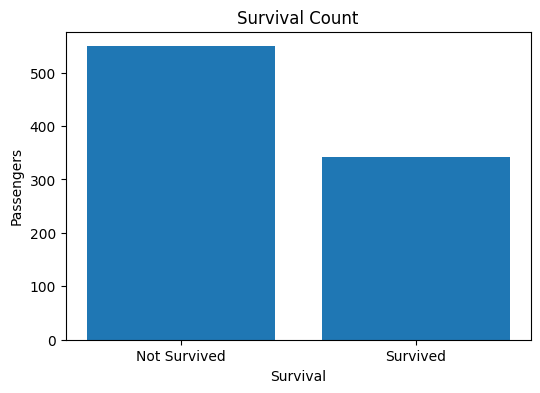

In [10]:
survival = df["Survived"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(["Not Survived","Survived"], survival.values)
plt.title("Survival Count")
plt.xlabel("Survival")
plt.ylabel("Passengers")
plt.show()

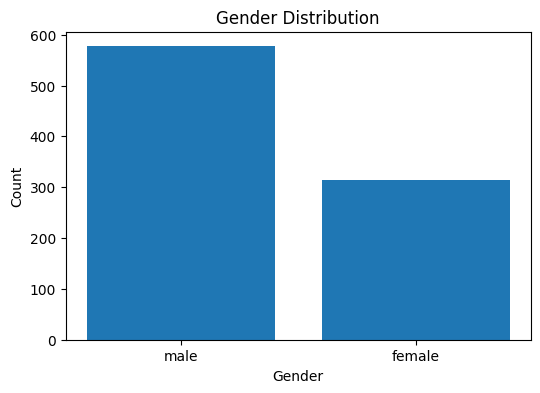

In [11]:
gender = df["Sex"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(gender.index, gender.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

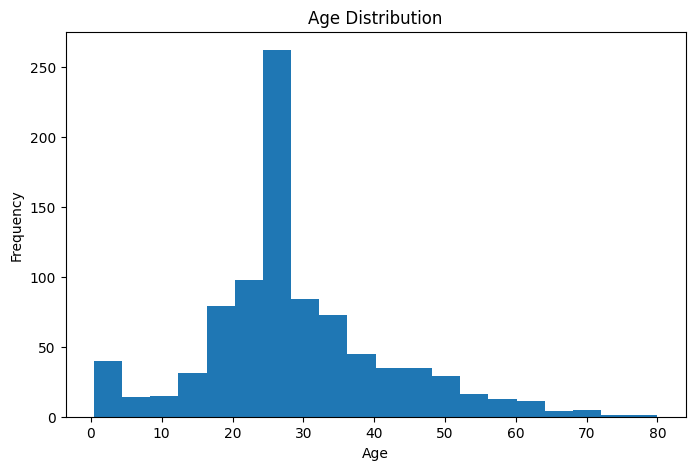

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

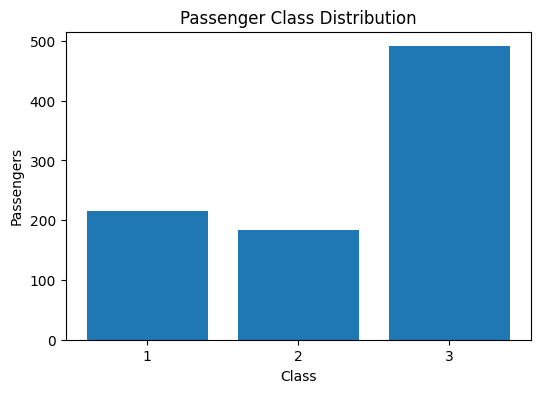

In [13]:
pclass = df["Pclass"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(pclass.index.astype(str), pclass.values)
plt.title("Passenger Class Distribution")
plt.xlabel("Class")
plt.ylabel("Passengers")
plt.show()

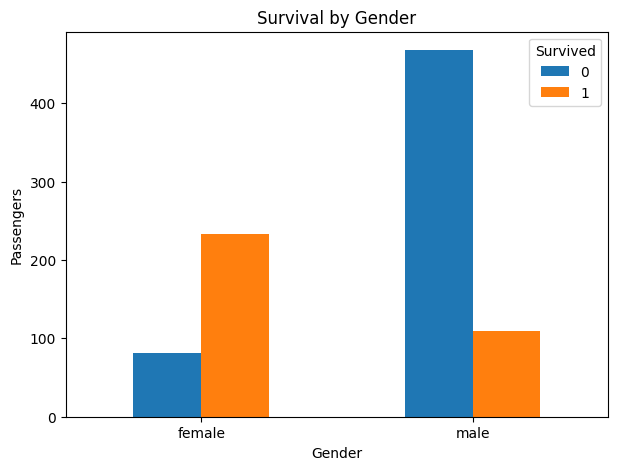

In [14]:
survival_gender = pd.crosstab(df["Sex"], df["Survived"])

survival_gender.plot(kind="bar", figsize=(7,5))

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Passengers")
plt.xticks(rotation=0)
plt.show()

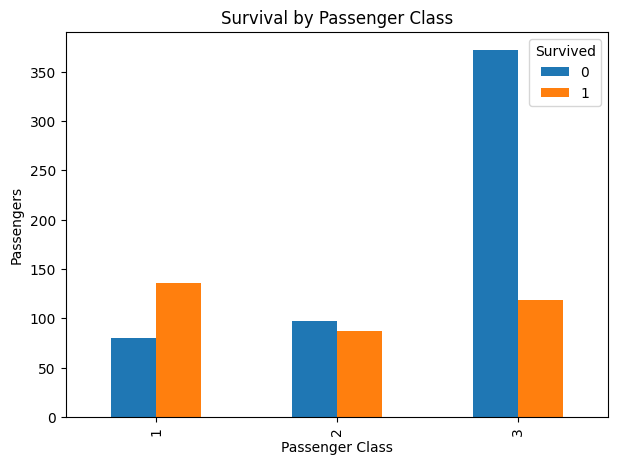

In [15]:
survival_class = pd.crosstab(df["Pclass"], df["Survived"])

survival_class.plot(kind="bar", figsize=(7,5))

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Passengers")
plt.show()